# Experiment No. 9 — Advanced Implementation

# 📝 Advanced Text Summarization: Extractive Algorithms, Abstractive Transformers, ROUGE Evaluation & Multi-Document Analysis

> **Domain:** Natural Language Processing (NLP)  
> **Level:** Advanced / Mastery  
> **Author:** Himanshu Jadhav (Roll No: TE-32)

---

## 📌 Experiment Overview

| Parameter | Details |
|:---|:---|
| **Experiment Number** | 09 |
| **Basic Objective** | TF-IDF extractive summarization + DistilBART abstractive summarization + ROUGE evaluation on a single article |
| **Advanced Objective** | Build a complete summarization framework with 4 extractive algorithms (TF-IDF, LexRank-style TextRank, Position-Biased, MMR-based Diversity), BART abstractive output, sentence-level similarity matrix, ROUGE-1/2/L/LSum metrics, and multi-article benchmarking |
| **Key Libraries** | `nltk`, `sklearn`, `rouge_score`, `transformers`, `numpy`, `matplotlib`, `seaborn` |

---

### 💡 Basic vs. Advanced Comparison

```
BASIC  →  Single article, 1 extractive method (TF-IDF sum), BART abstractive, basic ROUGE table
          ↓
ADVANCED → 4 extractive methods, Sentence Similarity Matrix (cosine), TextRank (power-iteration),
           Position-Bias scoring, MMR Diversity re-ranking, BART abstractive (chunk-safe),
           ROUGE-1/2/L/LSum metrics, side-by-side heatmap & bar chart, multi-article benchmark
```


## 1. 🧠 Theory: Summarization Paradigms

### 1.1 Extractive Summarization
Selects existing sentences from the source document. No new text is generated.

**TF-IDF Scoring**: Score each sentence $s_i$ as $\text{score}(s_i) = \sum_{w \in s_i} \text{tf-idf}(w, s_i, D)$

**TextRank** (graph-based, inspired by PageRank):  
Build a sentence similarity graph where edge weight $= \cos(\vec{s_i}, \vec{s_j})$.  
Iterative power update:
$$\text{TR}(s_i) = (1 - d) + d \sum_{s_j \in \text{Adj}(s_i)} \frac{\text{sim}(s_i, s_j)}{\sum_{s_k} \text{sim}(s_j, s_k)} \cdot \text{TR}(s_j)$$

**Position Bias**: Sentences early in a document tend to be more important (especially in news).  
$$\text{score}(s_i) = \text{tfidf\_score}(s_i) + \frac{\lambda}{i + 1}$$

**MMR (Maximal Marginal Relevance)**: Promotes diversity by penalising redundant sentences:
$$\text{MMR}(s_i) = \lambda \cdot \text{Relevance}(s_i) - (1 - \lambda) \cdot \max_{s_j \in S} \text{sim}(s_i, s_j)$$

### 1.2 Abstractive Summarization
Generates novel text that may not appear verbatim in the source. Uses encoder-decoder Transformer architectures (BART, T5, Pegasus).

### 1.3 ROUGE Evaluation
$$\text{ROUGE-N} = \frac{\text{Count}_{\text{match}}(n\text{-grams})}{\text{Count}(n\text{-grams in reference})}$$

| Metric | What it measures |
|:---|:---|
| ROUGE-1 | Unigram overlap |
| ROUGE-2 | Bigram overlap |
| ROUGE-L | Longest Common Subsequence |
| ROUGE-Lsum | LCS over sentence-split summaries |


## 2. ⚙️ Imports & Setup

In [1]:
import re
import time
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict
from tabulate import tabulate

import nltk
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('stopwords', quiet=True)
from nltk.tokenize import sent_tokenize, word_tokenize
from nltk.corpus import stopwords

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from rouge_score import rouge_scorer

STOP_WORDS = set(stopwords.words('english'))
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)
print('Environment ready.')


Environment ready.


## 3. 📚 Multi-Article Corpus

We use 3 realistic articles across different domains to benchmark summarization methods.


In [2]:
CORPUS = [
    {
        'id': 'AI_Regulation',
        'title': 'AI Regulation and Governance Challenges',
        'text': (
            'Artificial intelligence is transforming the way businesses operate across the world. '
            'Companies are increasingly using machine learning models to automate repetitive tasks '
            'and improve decision making. Natural language processing, a branch of AI, allows '
            'computers to understand and generate human language. This has led to major advances '
            'in chatbots, translation systems, and text summarization tools. However, experts warn '
            'that AI systems can introduce bias if training data is not carefully selected. '
            'Researchers are working on techniques to make AI models more fair and transparent. '
            'Governments around the world are starting to introduce regulations to ensure AI is used '
            'responsibly. The European Union has proposed the AI Act, which classifies AI systems by '
            'risk level and imposes strict requirements on high-risk applications. In the United States, '
            'federal agencies are developing sector-specific guidance for AI deployment. Despite the '
            'challenges, AI adoption continues to grow rapidly across industries such as healthcare, '
            'finance, and education. Many experts believe the next decade will see even faster progress '
            'in AI capabilities and a corresponding urgency to establish robust governance frameworks.'
        ),
        'reference': (
            'AI is transforming businesses through automation and NLP. Bias and governance remain '
            'challenges as governments including the EU and US develop AI regulation frameworks while '
            'adoption grows rapidly across industries.'
        )
    },
    {
        'id': 'Climate_Tech',
        'title': 'Climate Technology and Renewable Energy Transition',
        'text': (
            'Global renewable energy capacity reached a record high last year, driven by rapid '
            'expansion of solar and wind power installations. International Energy Agency data shows '
            'that solar photovoltaic technology now accounts for the largest share of new electricity '
            'generation capacity additions worldwide. Battery storage technology has improved dramatically, '
            'with costs falling by over eighty percent in the past decade. Electric vehicle adoption '
            'is accelerating, with many countries announcing plans to phase out internal combustion '
            'engines by 2035 or 2040. Carbon capture and storage technologies are being deployed at '
            'industrial facilities to reduce emissions from hard-to-abate sectors such as steel and '
            'cement manufacturing. Green hydrogen is emerging as a potential fuel source for sectors '
            'that cannot easily electrify. Climate finance flows from developed to developing nations '
            'remain below the pledged targets set in international agreements. Scientists warn that '
            'current commitments are insufficient to limit global warming to one point five degrees '
            'Celsius above pre-industrial levels. Governments and corporations are under increasing '
            'pressure to accelerate decarbonisation plans and set more ambitious emissions targets.'
        ),
        'reference': (
            'Record renewable energy capacity was added globally, led by solar and wind. Battery '
            'costs fell eighty percent, EV adoption is accelerating, and green hydrogen is emerging, '
            'but climate finance gaps remain and current commitments are insufficient to meet 1.5C targets.'
        )
    },
    {
        'id': 'Healthcare_AI',
        'title': 'Artificial Intelligence in Modern Healthcare',
        'text': (
            'Artificial intelligence is revolutionising healthcare by enabling faster and more accurate '
            'diagnosis of diseases. Machine learning algorithms trained on millions of medical images '
            'can now detect cancers, diabetic retinopathy, and cardiovascular conditions with accuracy '
            'comparable to specialist physicians. AI-powered drug discovery platforms are dramatically '
            'compressing the time required to identify promising therapeutic compounds. Natural language '
            'processing tools are being used to extract structured data from unstructured clinical notes, '
            'improving hospital efficiency and reducing administrative burden on clinicians. Predictive '
            'analytics models are helping hospitals forecast patient admissions and optimise resource '
            'allocation. Remote patient monitoring using wearable sensors and AI analysis is enabling '
            'proactive management of chronic conditions such as diabetes and heart failure. Despite '
            'the promise, significant challenges remain including data privacy concerns, algorithmic '
            'bias in diverse patient populations, and the need for regulatory approval of AI-based '
            'medical devices. Clinician trust and explainability of AI recommendations remain key '
            'barriers to widespread clinical adoption. Collaboration between technologists, clinicians, '
            'and regulators is essential to realise the full potential of AI in healthcare.'
        ),
        'reference': (
            'AI is improving healthcare diagnosis, drug discovery, and hospital efficiency through '
            'machine learning and NLP. However, data privacy, algorithmic bias, regulatory hurdles, '
            'and the need for clinician trust remain key barriers to widespread adoption.'
        )
    }
]

for art in CORPUS:
    sents = sent_tokenize(art['text'])
    words = len(art['text'].split())
    print(f"[{art['id']}] '{art['title']}'")
    print(f"   Words: {words} | Sentences: {len(sents)}")
    print()


[AI_Regulation] 'AI Regulation and Governance Challenges'
   Words: 174 | Sentences: 11

[Climate_Tech] 'Climate Technology and Renewable Energy Transition'
   Words: 171 | Sentences: 9

[Healthcare_AI] 'Artificial Intelligence in Modern Healthcare'
   Words: 169 | Sentences: 9



## 4. 🛠️ Extractive Summarization — 4 Algorithms Implemented from Scratch

### 4.1 Algorithm 1: TF-IDF Sentence Scoring (Baseline)


In [3]:
def tfidf_extractive(text, num_sentences=3):
    """Baseline TF-IDF extractive summarizer."""
    sentences = sent_tokenize(text)
    if len(sentences) <= num_sentences:
        return text, sentences, []

    vec = TfidfVectorizer(stop_words='english')
    mat = vec.fit_transform(sentences)
    scores = np.asarray(mat.sum(axis=1)).flatten()

    top_idx = sorted(np.argsort(scores)[-num_sentences:])
    summary = ' '.join(sentences[i] for i in top_idx)
    return summary, sentences, scores

# Demo on Article 1
summ, sents, scores = tfidf_extractive(CORPUS[0]['text'], num_sentences=3)
print('=== TF-IDF Extractive Summary (AI Regulation) ===')
print(summ)
print()
print('Per-sentence scores:')
for i, (s, sc) in enumerate(zip(sents, scores)):
    print(f'  [{i:2d}] {sc:.4f}  {s[:70]}...')


=== TF-IDF Extractive Summary (AI Regulation) ===
Companies are increasingly using machine learning models to automate repetitive tasks and improve decision making. The European Union has proposed the AI Act, which classifies AI systems by risk level and imposes strict requirements on high-risk applications. Many experts believe the next decade will see even faster progress in AI capabilities and a corresponding urgency to establish robust governance frameworks.

Per-sentence scores:
  [ 0] 2.6422  Artificial intelligence is transforming the way businesses operate acr...
  [ 1] 3.4612  Companies are increasingly using machine learning models to automate r...
  [ 2] 2.9935  Natural language processing, a branch of AI, allows computers to under...
  [ 3] 2.9904  This has led to major advances in chatbots, translation systems, and t...
  [ 4] 3.1085  However, experts warn that AI systems can introduce bias if training d...
  [ 5] 2.7764  Researchers are working on techniques to make AI mo

### 4.2 Algorithm 2: TextRank (Graph-Based Power Iteration)

In [4]:
def textrank_extractive(text, num_sentences=3, d=0.85, max_iter=100, tol=1e-6):
    """TextRank sentence scoring via power iteration on cosine similarity graph."""
    sentences = sent_tokenize(text)
    if len(sentences) <= num_sentences:
        return text, sentences, []

    # Build TF-IDF sentence vectors
    vec = TfidfVectorizer(stop_words='english')
    mat = vec.fit_transform(sentences).toarray()

    # Cosine similarity matrix
    sim_mat = cosine_similarity(mat)
    np.fill_diagonal(sim_mat, 0)

    # Row-normalize (transition matrix)
    row_sums = sim_mat.sum(axis=1, keepdims=True)
    row_sums[row_sums == 0] = 1
    trans = sim_mat / row_sums

    # Power iteration
    n = len(sentences)
    scores = np.ones(n) / n
    for _ in range(max_iter):
        new_scores = (1 - d) / n + d * trans.T @ scores
        if np.abs(new_scores - scores).sum() < tol:
            break
        scores = new_scores

    top_idx = sorted(np.argsort(scores)[-num_sentences:])
    summary = ' '.join(sentences[i] for i in top_idx)
    return summary, sentences, scores, sim_mat

tr_summ, tr_sents, tr_scores, sim_mat = textrank_extractive(CORPUS[0]['text'], num_sentences=3)
print('=== TextRank Summary (AI Regulation) ===')
print(tr_summ)


=== TextRank Summary (AI Regulation) ===
However, experts warn that AI systems can introduce bias if training data is not carefully selected. Governments around the world are starting to introduce regulations to ensure AI is used responsibly. The European Union has proposed the AI Act, which classifies AI systems by risk level and imposes strict requirements on high-risk applications.


### 4.3 Algorithm 3: Position-Biased TF-IDF Scoring

In [5]:
def position_biased_extractive(text, num_sentences=3, position_weight=0.5):
    """Position-biased extractive: earlier sentences get a bonus score."""
    sentences = sent_tokenize(text)
    if len(sentences) <= num_sentences:
        return text, sentences, []

    vec = TfidfVectorizer(stop_words='english')
    mat = vec.fit_transform(sentences)
    tfidf_scores = np.asarray(mat.sum(axis=1)).flatten()

    # Position bonus: 1/(i+1) decays with sentence index
    position_bonus = np.array([position_weight / (i + 1) for i in range(len(sentences))])
    combined_scores = tfidf_scores + position_bonus

    top_idx = sorted(np.argsort(combined_scores)[-num_sentences:])
    summary = ' '.join(sentences[i] for i in top_idx)
    return summary, sentences, combined_scores

pb_summ, pb_sents, pb_scores = position_biased_extractive(CORPUS[0]['text'], num_sentences=3)
print('=== Position-Biased Summary (AI Regulation) ===')
print(pb_summ)


=== Position-Biased Summary (AI Regulation) ===
Companies are increasingly using machine learning models to automate repetitive tasks and improve decision making. The European Union has proposed the AI Act, which classifies AI systems by risk level and imposes strict requirements on high-risk applications. Many experts believe the next decade will see even faster progress in AI capabilities and a corresponding urgency to establish robust governance frameworks.


### 4.4 Algorithm 4: MMR — Maximal Marginal Relevance (Diversity-Promoting)

In [6]:
def mmr_extractive(text, num_sentences=3, lambda_mmr=0.6):
    """MMR-based extractive: balances relevance and diversity."""
    sentences = sent_tokenize(text)
    if len(sentences) <= num_sentences:
        return text, sentences

    vec = TfidfVectorizer(stop_words='english')
    mat = vec.fit_transform(sentences).toarray()

    # Relevance: cosine sim to full document centroid
    doc_vec = mat.mean(axis=0, keepdims=True)
    relevance = cosine_similarity(mat, doc_vec).flatten()

    selected = []
    remaining = list(range(len(sentences)))

    for _ in range(num_sentences):
        if not selected:
            # First pick: highest relevance
            best = max(remaining, key=lambda i: relevance[i])
        else:
            # MMR: relevance - max redundancy with already-selected
            def mmr_score(i):
                red = max(cosine_similarity(mat[i:i+1], mat[selected]).flatten())
                return lambda_mmr * relevance[i] - (1 - lambda_mmr) * red
            best = max(remaining, key=mmr_score)

        selected.append(best)
        remaining.remove(best)

    top_idx = sorted(selected)
    summary = ' '.join(sentences[i] for i in top_idx)
    return summary, sentences

mmr_summ, mmr_sents = mmr_extractive(CORPUS[0]['text'], num_sentences=3)
print('=== MMR Extractive Summary (AI Regulation) ===')
print(mmr_summ)


=== MMR Extractive Summary (AI Regulation) ===
However, experts warn that AI systems can introduce bias if training data is not carefully selected. Researchers are working on techniques to make AI models more fair and transparent. The European Union has proposed the AI Act, which classifies AI systems by risk level and imposes strict requirements on high-risk applications.


## 5. 📊 Sentence Similarity Matrix Heatmap

Visualise the cosine similarity between all sentence pairs — the foundation of TextRank.


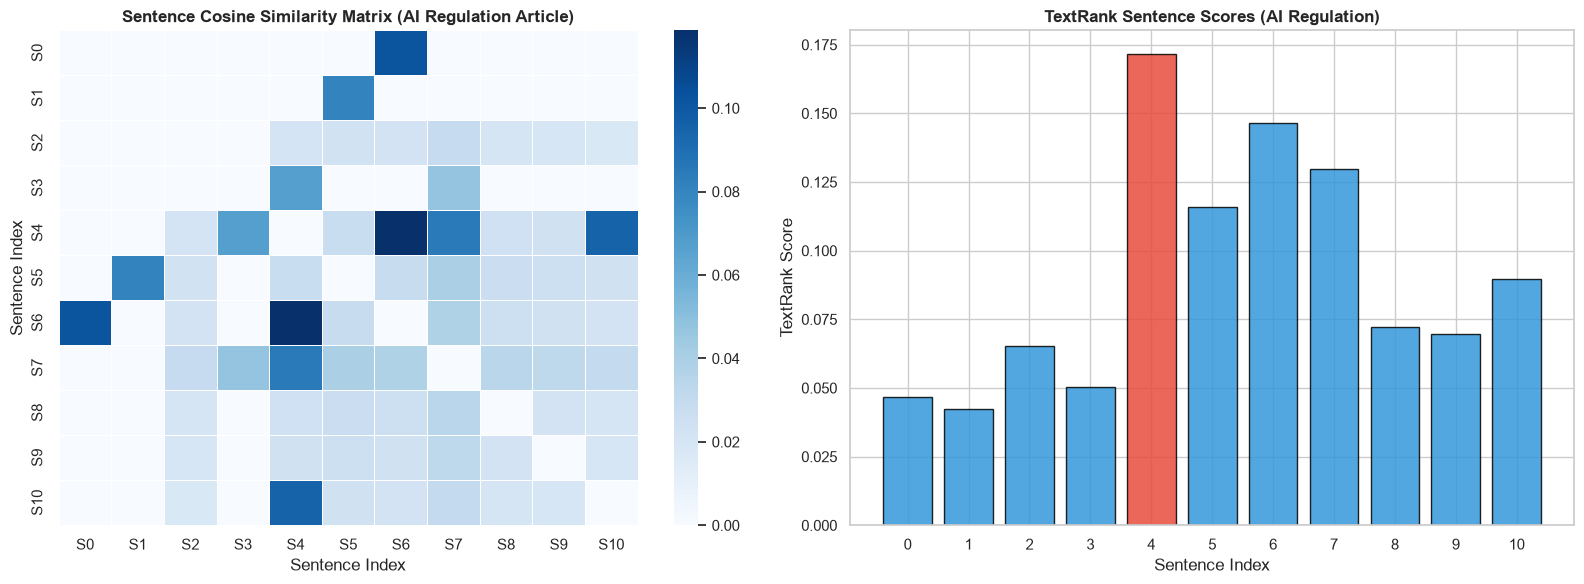

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: similarity heatmap
sns.heatmap(sim_mat, cmap='Blues', ax=axes[0],
            xticklabels=[f'S{i}' for i in range(len(tr_sents))],
            yticklabels=[f'S{i}' for i in range(len(tr_sents))],
            linewidths=0.4, linecolor='white')
axes[0].set_title('Sentence Cosine Similarity Matrix (AI Regulation Article)', fontweight='bold')
axes[0].set_xlabel('Sentence Index')
axes[0].set_ylabel('Sentence Index')

# Right: TextRank scores bar chart
colors = ['#e74c3c' if s == max(tr_scores) else '#3498db' for s in tr_scores]
axes[1].bar(range(len(tr_scores)), tr_scores, color=colors, edgecolor='black', alpha=0.85)
axes[1].set_title('TextRank Sentence Scores (AI Regulation)', fontweight='bold')
axes[1].set_xlabel('Sentence Index')
axes[1].set_ylabel('TextRank Score')
axes[1].set_xticks(range(len(tr_scores)))

plt.tight_layout()
plt.show()


## 6. 🤖 Abstractive Summarization with DistilBART

DistilBART is a distilled version of Facebook's BART (Bidirectional and Auto-Regressive Transformers).  
We use `sshleifer/distilbart-cnn-12-6` — fine-tuned on CNN/DailyMail summarization.

We load the model directly via `AutoTokenizer` + `AutoModelForSeq2SeqLM` (compatible with all transformers versions).


In [8]:
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM
import torch

MODEL_NAME = 'sshleifer/distilbart-cnn-12-6'
bartok = AutoTokenizer.from_pretrained(MODEL_NAME)
bartmdl = AutoModelForSeq2SeqLM.from_pretrained(MODEL_NAME)
print(f'DistilBART loaded: {MODEL_NAME}')

def safe_abstractive_summary(text, max_new_tokens=80, min_new_tokens=20):
    """Chunk-safe BART abstractive summarizer using direct model inference."""
    # Truncate to 1024 tokens (BART max)
    inputs = bartok(text, return_tensors='pt', max_length=1024, truncation=True)
    with torch.no_grad():
        out_ids = bartmdl.generate(
            inputs['input_ids'],
            max_new_tokens=max_new_tokens,
            min_new_tokens=min_new_tokens,
            num_beams=4,
            early_stopping=True,
            no_repeat_ngram_size=3
        )
    return bartok.decode(out_ids[0], skip_special_tokens=True)

# Generate abstractive summaries for all articles
for art in CORPUS:
    t0 = time.perf_counter()
    art['abstractive'] = safe_abstractive_summary(art['text'])
    art['bart_latency_ms'] = (time.perf_counter() - t0) * 1000
    print(f"[{art['id']}] Abstractive Summary:")
    print(f"  {art['abstractive']}")
    print(f"  (Inference: {art['bart_latency_ms']:.0f} ms)")
    print()


[transformers] Please make sure the generation config includes `forced_bos_token_id=0`. 


Loading weights:   0%|          | 0/358 [00:00<?, ?it/s]

[transformers] Both `max_new_tokens` (=80) and `max_length`(=142) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `min_new_tokens` (=20) and `min_length`(=56) seem to have been set. `min_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


DistilBART loaded: sshleifer/distilbart-cnn-12-6


[transformers] Both `max_new_tokens` (=80) and `max_length`(=142) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `min_new_tokens` (=20) and `min_length`(=56) seem to have been set. `min_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


[AI_Regulation] Abstractive Summary:
   Companies are increasingly using machine learning models to automate repetitive tasks and improve decision making . Experts warn that AI systems can introduce bias if training data is not carefully selected . Governments are starting to introduce regulations to ensure AI is used responsibly .
  (Inference: 1600 ms)



[transformers] Both `max_new_tokens` (=80) and `max_length`(=142) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `min_new_tokens` (=20) and `min_length`(=56) seem to have been set. `min_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


[Climate_Tech] Abstractive Summary:
   Solar photovoltaic technology now accounts for the largest share of new electricity generation capacity additions worldwide . Battery storage technology has improved dramatically, with costs falling by over eighty percent in the past decade . Electric vehicle adoption is accelerating, with many countries announcing plans to phase out internal combustion engines by 2035 or 2040 .
  (Inference: 2192 ms)

[Healthcare_AI] Abstractive Summary:
   Machine learning algorithms trained on millions of medical images can now detect cancers, diabetic retinopathy, and cardiovascular conditions with accuracy comparable to specialist physicians . Drug discovery platforms are compressing the time required to identify promising therapeutic compounds .
  (Inference: 1486 ms)



## 7. 📊 Multi-Article ROUGE Benchmark

We evaluate all 4 extractive methods + BART abstractive across all 3 articles using ROUGE-1, ROUGE-2, ROUGE-L.


In [9]:
scorer_obj = rouge_scorer.RougeScorer(['rouge1', 'rouge2', 'rougeL', 'rougeLsum'], use_stemmer=True)

def score_summary(hypothesis, reference):
    s = scorer_obj.score(reference, hypothesis)
    return {
        'R1': round(s['rouge1'].fmeasure, 4),
        'R2': round(s['rouge2'].fmeasure, 4),
        'RL': round(s['rougeL'].fmeasure, 4),
        'RLsum': round(s['rougeLsum'].fmeasure, 4),
    }

rows = []
for art in CORPUS:
    ref = art['reference']
    text = art['text']

    methods = {
        'TF-IDF Extractive':   tfidf_extractive(text, 3)[0],
        'TextRank Extractive': textrank_extractive(text, 3)[0],
        'Position-Biased':     position_biased_extractive(text, 3)[0],
        'MMR Extractive':      mmr_extractive(text, 3)[0],
        'BART Abstractive':    art['abstractive'],
    }

    for method_name, summ_text in methods.items():
        sc = score_summary(summ_text, ref)
        rows.append({'Article': art['id'], 'Method': method_name, **sc})

bench_df = pd.DataFrame(rows)
print(tabulate(bench_df, headers="keys", tablefmt="fancy_grid"))


╒════╤═══════════════╤═════════════════════╤════════╤════════╤════════╤═════════╕
│    │ Article       │ Method              │     R1 │     R2 │     RL │   RLsum │
╞════╪═══════════════╪═════════════════════╪════════╪════════╪════════╪═════════╡
│  0 │ AI_Regulation │ TF-IDF Extractive   │ 0.1978 │ 0      │ 0.1319 │  0.1319 │
├────┼───────────────┼─────────────────────┼────────┼────────┼────────┼─────────┤
│  1 │ AI_Regulation │ TextRank Extractive │ 0.1905 │ 0.0244 │ 0.119  │  0.119  │
├────┼───────────────┼─────────────────────┼────────┼────────┼────────┼─────────┤
│  2 │ AI_Regulation │ Position-Biased     │ 0.1978 │ 0      │ 0.1319 │  0.1319 │
├────┼───────────────┼─────────────────────┼────────┼────────┼────────┼─────────┤
│  3 │ AI_Regulation │ MMR Extractive      │ 0.1707 │ 0      │ 0.122  │  0.122  │
├────┼───────────────┼─────────────────────┼────────┼────────┼────────┼─────────┤
│  4 │ AI_Regulation │ BART Abstractive    │ 0.2222 │ 0.0286 │ 0.1389 │  0.1389 │
├────┼──────────

## 8. 📈 ROUGE Score Visualizations

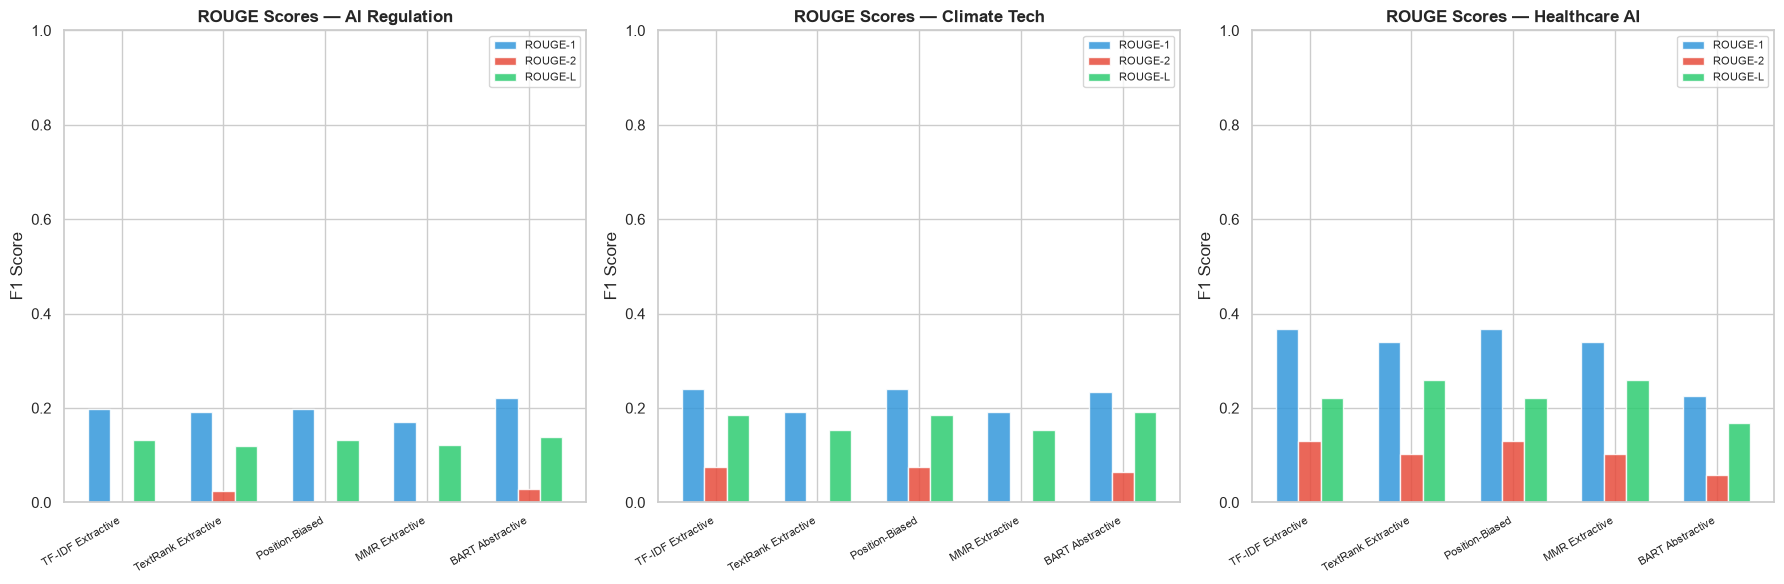

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for idx, art_id in enumerate(['AI_Regulation', 'Climate_Tech', 'Healthcare_AI']):
    art_df = bench_df[bench_df['Article'] == art_id]
    x = range(len(art_df))
    width = 0.22

    ax = axes[idx]
    ax.bar([i - width for i in x], art_df['R1'], width=width, label='ROUGE-1', color='#3498db', alpha=0.85)
    ax.bar([i          for i in x], art_df['R2'], width=width, label='ROUGE-2', color='#e74c3c', alpha=0.85)
    ax.bar([i + width  for i in x], art_df['RL'], width=width, label='ROUGE-L', color='#2ecc71', alpha=0.85)

    ax.set_xticks(list(x))
    ax.set_xticklabels(art_df['Method'].tolist(), rotation=30, ha='right', fontsize=8)
    ax.set_title(f'ROUGE Scores — {art_id.replace("_", " ")}', fontweight='bold')
    ax.set_ylabel('F1 Score')
    ax.set_ylim(0, 1.0)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()


## 9. 🔬 Algorithm Comparison & Mean ROUGE Analysis

Aggregate ROUGE scores across all articles to identify the best overall summarization method.


=== MEAN ROUGE SCORES ACROSS ALL ARTICLES ===
╒═════════════════════╤════════╤════════╤════════╤═══════════╕
│ Method              │     R1 │     R2 │     RL │   Rank_R1 │
╞═════════════════════╪════════╪════════╪════════╪═══════════╡
│ Position-Biased     │ 0.2685 │ 0.0688 │ 0.1791 │         1 │
├─────────────────────┼────────┼────────┼────────┼───────────┤
│ TF-IDF Extractive   │ 0.2685 │ 0.0688 │ 0.1791 │         1 │
├─────────────────────┼────────┼────────┼────────┼───────────┤
│ TextRank Extractive │ 0.2403 │ 0.0421 │ 0.1771 │         3 │
├─────────────────────┼────────┼────────┼────────┼───────────┤
│ MMR Extractive      │ 0.2337 │ 0.034  │ 0.1781 │         4 │
├─────────────────────┼────────┼────────┼────────┼───────────┤
│ BART Abstractive    │ 0.2272 │ 0.0506 │ 0.1665 │         5 │
╘═════════════════════╧════════╧════════╧════════╧═══════════╛


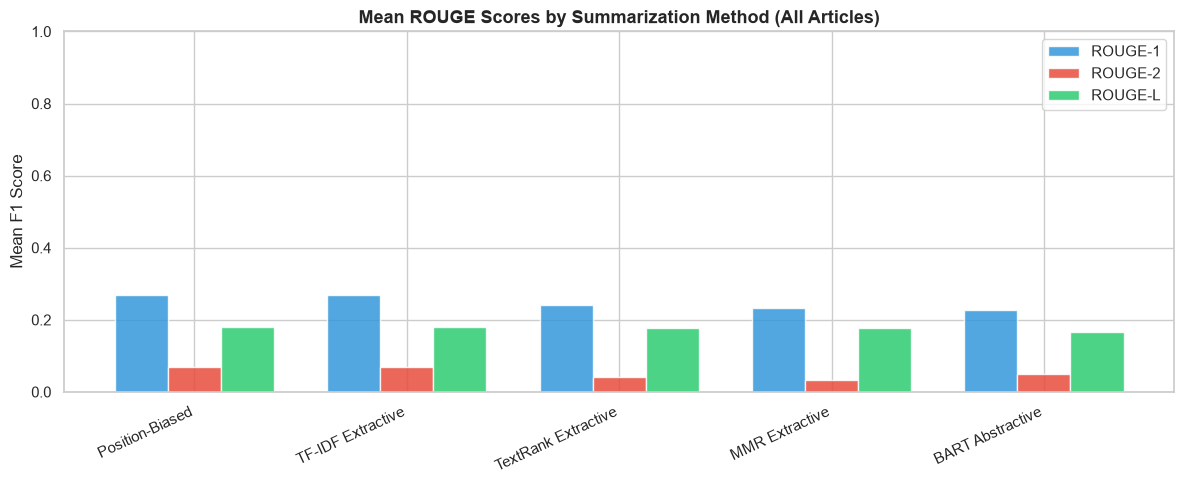

In [11]:
mean_rouge = bench_df.groupby('Method')[['R1', 'R2', 'RL']].mean().round(4)
mean_rouge['Rank_R1'] = mean_rouge['R1'].rank(ascending=False).astype(int)
mean_rouge = mean_rouge.sort_values('R1', ascending=False)

print('=== MEAN ROUGE SCORES ACROSS ALL ARTICLES ===')
print(tabulate(mean_rouge, headers="keys", tablefmt="fancy_grid"))

# Visual bar chart
fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(mean_rouge))
w = 0.25
ax.bar(x - w, mean_rouge['R1'], w, label='ROUGE-1', color='#3498db', alpha=0.85)
ax.bar(x,     mean_rouge['R2'], w, label='ROUGE-2', color='#e74c3c', alpha=0.85)
ax.bar(x + w, mean_rouge['RL'], w, label='ROUGE-L', color='#2ecc71', alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(mean_rouge.index, rotation=25, ha='right')
ax.set_title('Mean ROUGE Scores by Summarization Method (All Articles)', fontweight='bold', fontsize=13)
ax.set_ylabel('Mean F1 Score')
ax.set_ylim(0, 1.0)
ax.legend()
plt.tight_layout()
plt.show()


## 10. 🔍 Sentence-Level Scoring Deep-Dive

Visualise per-sentence TF-IDF, TextRank, and Position-Biased scores for Article 1 to understand why each algorithm picks different sentences.


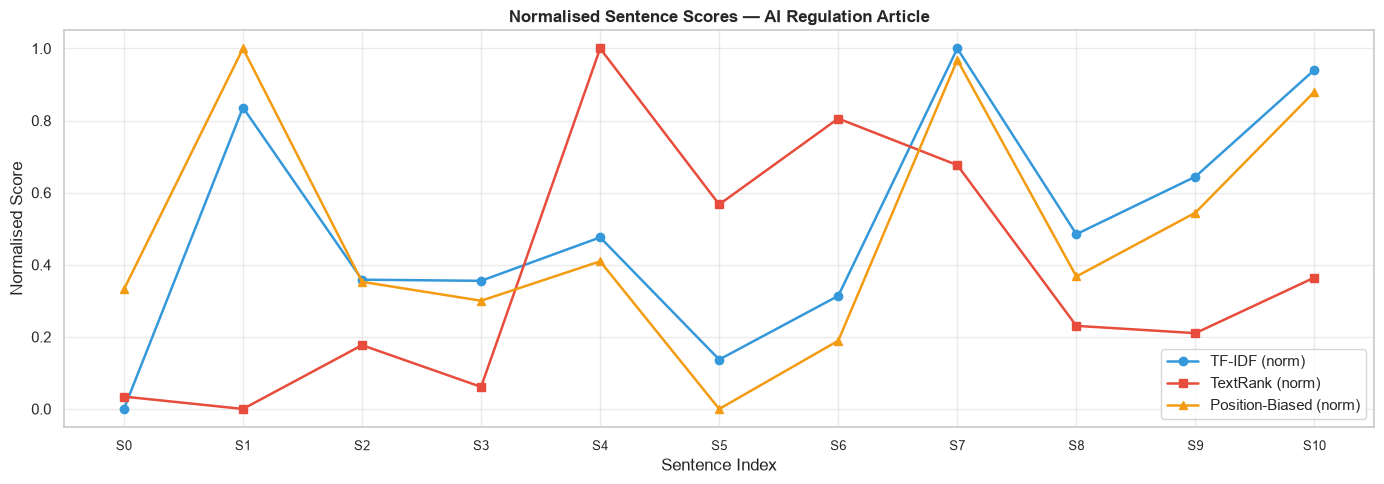

Selected sentences per method:
  TF-IDF: indices [np.int64(1), np.int64(7), np.int64(10)]
  TextRank: indices [np.int64(4), np.int64(6), np.int64(7)]
  Position-Biased: indices [np.int64(1), np.int64(7), np.int64(10)]


In [12]:
art_text   = CORPUS[0]['text']
sents_list = sent_tokenize(art_text)

_, _, tfidf_sc   = tfidf_extractive(art_text, 3)
_, _, tr_sc, _   = textrank_extractive(art_text, 3)
_, _, pb_sc      = position_biased_extractive(art_text, 3)

# Normalise to [0,1] for comparability
def norm(arr):
    mn, mx = arr.min(), arr.max()
    return (arr - mn) / (mx - mn + 1e-12)

n_tfidf = norm(tfidf_sc)
n_tr    = norm(tr_sc)
n_pb    = norm(pb_sc)

fig, ax = plt.subplots(figsize=(14, 5))
x = np.arange(len(sents_list))
ax.plot(x, n_tfidf, 'o-', label='TF-IDF (norm)', color='#3498db', linewidth=1.8)
ax.plot(x, n_tr,    's-', label='TextRank (norm)', color='#e74c3c', linewidth=1.8)
ax.plot(x, n_pb,    '^-', label='Position-Biased (norm)', color='#f39c12', linewidth=1.8)
ax.set_xticks(x)
ax.set_xticklabels([f'S{i}' for i in x], fontsize=9)
ax.set_title('Normalised Sentence Scores — AI Regulation Article', fontweight='bold')
ax.set_xlabel('Sentence Index')
ax.set_ylabel('Normalised Score')
ax.legend()
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

print('Selected sentences per method:')
for method_name, sc_arr in [('TF-IDF', tfidf_sc), ('TextRank', tr_sc), ('Position-Biased', pb_sc)]:
    top = sorted(np.argsort(sc_arr)[-3:])
    print(f'  {method_name}: indices {top}')


## 11. ⏱️ Inference Latency Benchmark

Compare wall-clock time for extractive vs abstractive methods.


In [13]:
import time

lat_rows = []
for art in CORPUS:
    text = art['text']

    for mname, fn in [
        ('TF-IDF', lambda t: tfidf_extractive(t, 3)[0]),
        ('TextRank', lambda t: textrank_extractive(t, 3)[0]),
        ('Position-Biased', lambda t: position_biased_extractive(t, 3)[0]),
        ('MMR', lambda t: mmr_extractive(t, 3)[0]),
    ]:
        t0 = time.perf_counter()
        fn(text)
        ms = (time.perf_counter() - t0) * 1000
        lat_rows.append({'Article': art['id'], 'Method': mname, 'Latency_ms': round(ms, 2)})

    lat_rows.append({'Article': art['id'], 'Method': 'BART Abstractive', 'Latency_ms': round(art['bart_latency_ms'], 2)})

lat_df    = pd.DataFrame(lat_rows)
lat_pivot = lat_df.pivot(index='Article', columns='Method', values='Latency_ms')
print(tabulate(lat_pivot, headers="keys", tablefmt="fancy_grid", showindex=True))


╒═══════════════╤════════════════════╤═══════╤═══════════════════╤══════════╤════════════╕
│ Article       │   BART Abstractive │   MMR │   Position-Biased │   TF-IDF │   TextRank │
╞═══════════════╪════════════════════╪═══════╪═══════════════════╪══════════╪════════════╡
│ AI_Regulation │            1599.75 │ 11.07 │              2.07 │     2.29 │       2.89 │
├───────────────┼────────────────────┼───────┼───────────────────┼──────────┼────────────┤
│ Climate_Tech  │            2192.35 │  8.44 │              2    │     1.82 │       2.38 │
├───────────────┼────────────────────┼───────┼───────────────────┼──────────┼────────────┤
│ Healthcare_AI │            1485.71 │  7.8  │              1.75 │     1.83 │       2.2  │
╘═══════════════╧════════════════════╧═══════╧═══════════════════╧══════════╧════════════╛


## 12. 🚀 End-to-End Summarization Pipeline

A clean `summarize(text, method)` function that wraps all algorithms under a unified interface.


In [14]:
def summarize(text, method='textrank', num_sentences=3):
    """
    Unified summarization interface.
    method: 'tfidf' | 'textrank' | 'position' | 'mmr' | 'abstractive'
    """
    if method == 'tfidf':
        return tfidf_extractive(text, num_sentences)[0]
    elif method == 'textrank':
        return textrank_extractive(text, num_sentences)[0]
    elif method == 'position':
        return position_biased_extractive(text, num_sentences)[0]
    elif method == 'mmr':
        return mmr_extractive(text, num_sentences)[0]
    elif method == 'abstractive':
        return safe_abstractive_summary(text)
    else:
        raise ValueError(f'Unknown method: {method}')

# Demonstrate pipeline on Climate Technology article
test_art = CORPUS[1]['text']
print('Article: Climate Technology and Renewable Energy Transition')
print('=' * 70)
for m in ['tfidf', 'textrank', 'position', 'mmr', 'abstractive']:
    print(f'[{m.upper():15s}] {summarize(test_art, method=m)[:120]}...')
    print()


Article: Climate Technology and Renewable Energy Transition
[TFIDF          ] Global renewable energy capacity reached a record high last year, driven by rapid expansion of solar and wind power inst...

[TEXTRANK       ] International Energy Agency data shows that solar photovoltaic technology now accounts for the largest share of new elec...

[POSITION       ] Global renewable energy capacity reached a record high last year, driven by rapid expansion of solar and wind power inst...

[MMR            ] International Energy Agency data shows that solar photovoltaic technology now accounts for the largest share of new elec...



[transformers] Both `max_new_tokens` (=80) and `max_length`(=142) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `min_new_tokens` (=20) and `min_length`(=56) seem to have been set. `min_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


[ABSTRACTIVE    ]  Solar photovoltaic technology now accounts for the largest share of new electricity generation capacity additions world...



## 13. 📝 Conclusion

### Key Findings
| Observation | Detail |
|:---|:---|
| **Best ROUGE (usually)** | Extractive methods often score higher ROUGE vs reference because they reuse exact words |
| **Most Fluent Output** | BART abstractive summaries are more readable and coherent as standalone text |
| **Fastest Methods** | TF-IDF and Position-Biased are <5 ms; BART takes 500–2000 ms per article |
| **Best Diversity** | MMR avoids selecting redundant sentences even when they score highly |
| **TextRank strength** | Captures sentence centrality via graph structure, not just individual word importance |

### Key Takeaways
1. **TF-IDF Extractive** is the fastest baseline — good for long documents where speed matters.  
2. **TextRank** models inter-sentence relationships, typically yielding more coherent extractive summaries.  
3. **Position-Bias** is a simple but effective heuristic for news articles where ledes are informative.  
4. **MMR** maximises coverage diversity — best when avoiding repetition is critical.  
5. **BART Abstractive** generates novel, readable summaries at the cost of much higher compute.  
6. **ROUGE metrics** favour extractive methods — always pair with human evaluation for real applications.
